<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS06/JS06_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS06 — Praktikum 1
## SVM dengan Data Linier

Praktikum ini membahas garis pemisah, margin, dan support vector pada SVM. Jalankan sel berurutan; data dibuat langsung dalam notebook.


### Langkah 1 — Import pustaka


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (8, 5), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=6, suppress=True)
print(f"NumPy {np.__version__} | scikit-learn {sklearn.__version__}")


NumPy 2.1.3 | scikit-learn 1.6.1


### Langkah 2 — Membuat data

Buat 50 data dalam dua kelas dengan seed tetap.


Ukuran X: (50, 2)
Jumlah data per kelas: {np.int64(0): np.int64(25), np.int64(1): np.int64(25)}


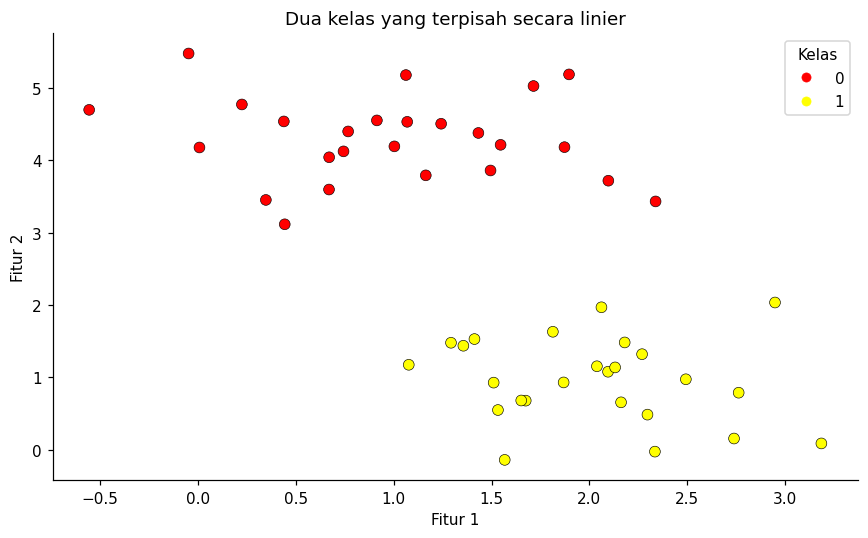

In [2]:
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)
print("Ukuran X:", X.shape)
print("Jumlah data per kelas:", dict(zip(*np.unique(y, return_counts=True))))
fig, ax = plt.subplots()
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="autumn", edgecolors="k", linewidths=0.4)
ax.set(xlabel="Fitur 1", ylabel="Fitur 2", title="Dua kelas yang terpisah secara linier")
ax.legend(*scatter.legend_elements(), title="Kelas")
plt.tight_layout()
plt.show()


### Langkah 3 — Garis pemisah

Beberapa garis dapat memisahkan kelas, tetapi prediksi titik baru bisa berbeda.


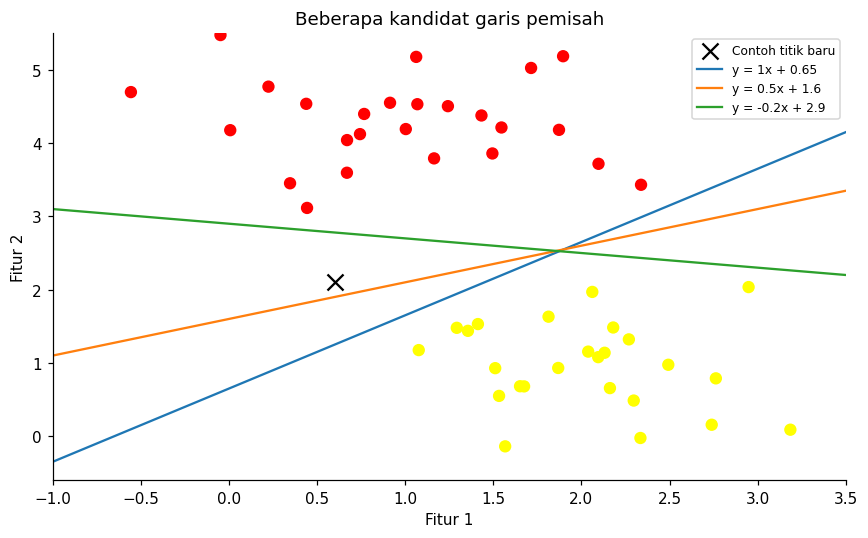

In [3]:
xfit = np.linspace(-1, 3.5, 200)
candidates = [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="autumn")
ax.scatter([0.6], [2.1], c="black", marker="x", s=110, label="Contoh titik baru")
for m, b, _ in candidates:
    ax.plot(xfit, m * xfit + b, label=f"y = {m:g}x + {b:g}")
ax.set(xlim=(-1, 3.5), ylim=(-0.6, 5.5), xlabel="Fitur 1", ylabel="Fitur 2",
       title="Beberapa kandidat garis pemisah")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Langkah 4 — Ilustrasi margin

Area abu-abu menunjukkan pita di sekitar garis; `d` adalah jarak vertikal pada ilustrasi ini.


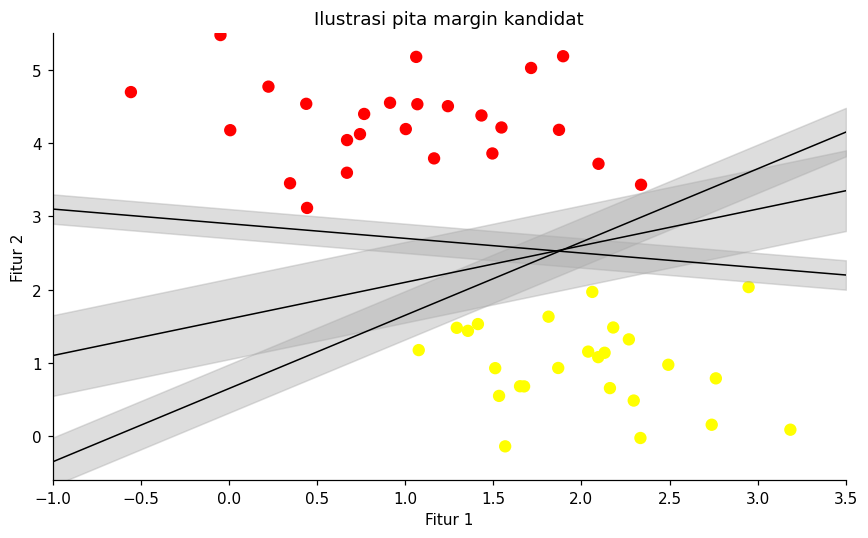

In [4]:
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="autumn")
for m, b, d in candidates:
    yfit = m * xfit + b
    ax.plot(xfit, yfit, "-k", linewidth=1)
    ax.fill_between(xfit, yfit - d, yfit + d, color="#AAAAAA", alpha=0.4)
ax.set(xlim=(-1, 3.5), ylim=(-0.6, 5.5), xlabel="Fitur 1", ylabel="Fitur 2",
       title="Ilustrasi pita margin kandidat")
plt.tight_layout()
plt.show()


### Langkah 5 — Melatih SVM

Gunakan kernel linier; lingkaran hitam menandai support vector.


In [5]:
model = SVC(kernel="linear", C=1E10)
model.fit(X, y)


SVC(C=10000000000.0, kernel='linear')

In [6]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Garis f(x)=0, kontur margin f(x)=±1, serta support vector."""
    if ax is None:
        ax = plt.gca()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 200))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    scores = model.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, scores, levels=[-1, 0, 1], colors="black",
               alpha=0.7, linestyles=["--", "-", "--"])
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=190, linewidths=1.2, facecolors="none", edgecolors="black",
                   label="Support vector")
    ax.set(xlim=xlim, ylim=ylim, xlabel="Fitur 1", ylabel="Fitur 2")
    return ax


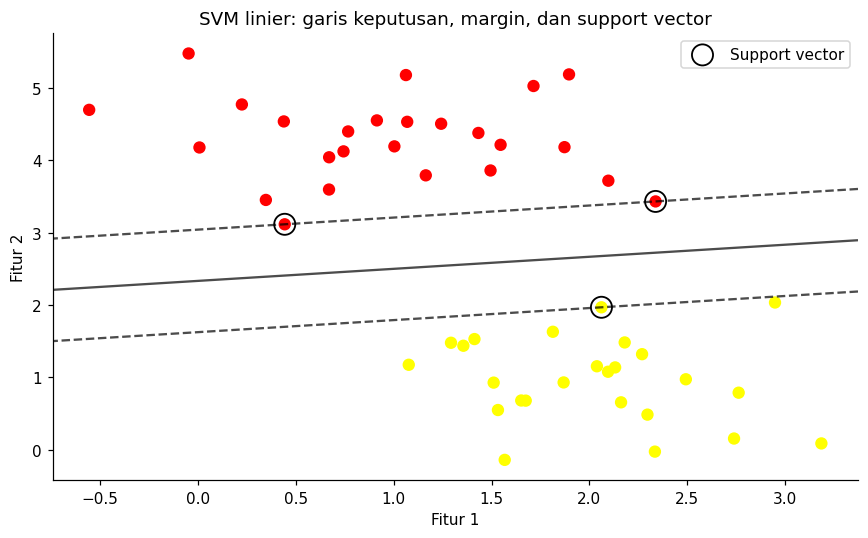

Koordinat support vector:
[[0.443599 3.115309]
 [2.338123 3.431168]
 [2.061568 1.969186]]
Indeks support vector: [18 25  7]
Jumlah support vector per kelas: [2 1]
Garis keputusan: 0.235257 x1 + -1.412508 x2 + 3.296342 = 0
Lebar margin geometris: 1.396682
Akurasi pada data latih: 100.00%


In [7]:
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap="autumn")
plot_svc_decision_function(model, ax)
ax.set_title("SVM linier: garis keputusan, margin, dan support vector")
ax.legend()
plt.tight_layout()
plt.show()

print("Koordinat support vector:")
print(model.support_vectors_)
print("Indeks support vector:", model.support_)
print("Jumlah support vector per kelas:", model.n_support_)
w, b = model.coef_[0], model.intercept_[0]
full_margin = 2 / np.linalg.norm(w)
print(f"Garis keputusan: {w[0]:.6f} x1 + {w[1]:.6f} x2 + {b:.6f} = 0")
print(f"Lebar margin geometris: {full_margin:.6f}")
print(f"Akurasi pada data latih: {model.score(X, y):.2%}")


### Percobaan 60 dan 120 data

Bandingkan model dari dua jumlah data yang diambil dari kumpulan yang sama.


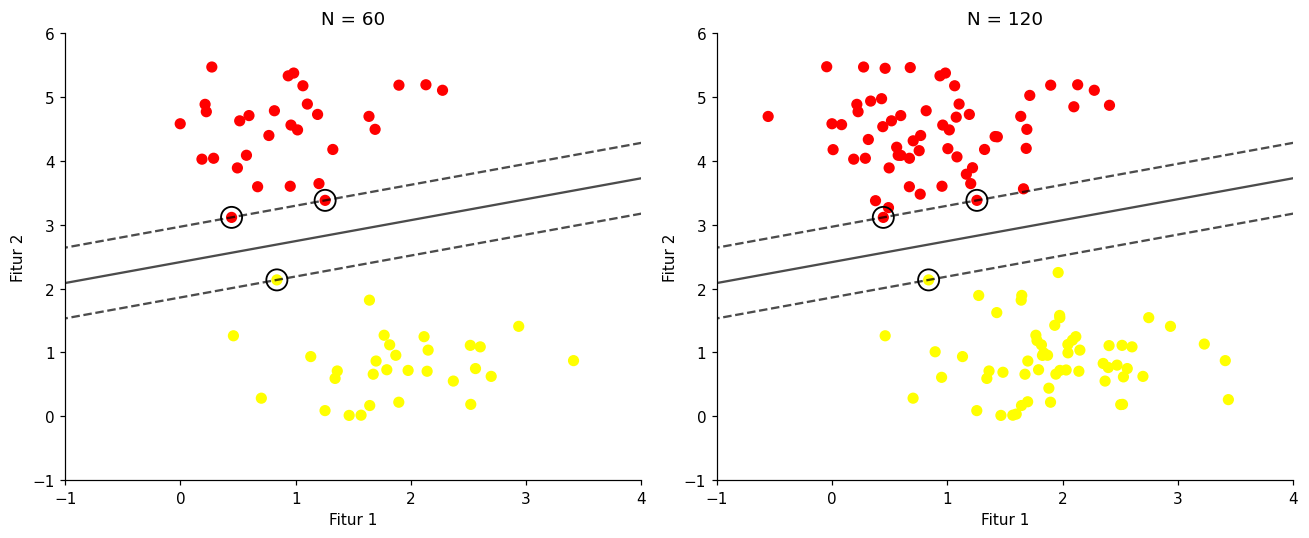

In [8]:
X_pool, y_pool = make_blobs(n_samples=200, centers=2, random_state=0, cluster_std=0.60)

def plot_svm(N=10, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    current = SVC(kernel="linear", C=1E10).fit(X_pool[:N], y_pool[:N])
    ax.scatter(X_pool[:N, 0], X_pool[:N, 1], c=y_pool[:N], s=40, cmap="autumn")
    ax.set(xlim=(-1, 4), ylim=(-1, 6), title=f"N = {N}")
    plot_svc_decision_function(current, ax)
    return current

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = {N: plot_svm(N, ax) for N, ax in zip([60, 120], axes)}
plt.tight_layout()
plt.show()


### Percobaan 10 dan 200 data

Grafik statis dan tabel digunakan untuk membandingkan perubahan model.


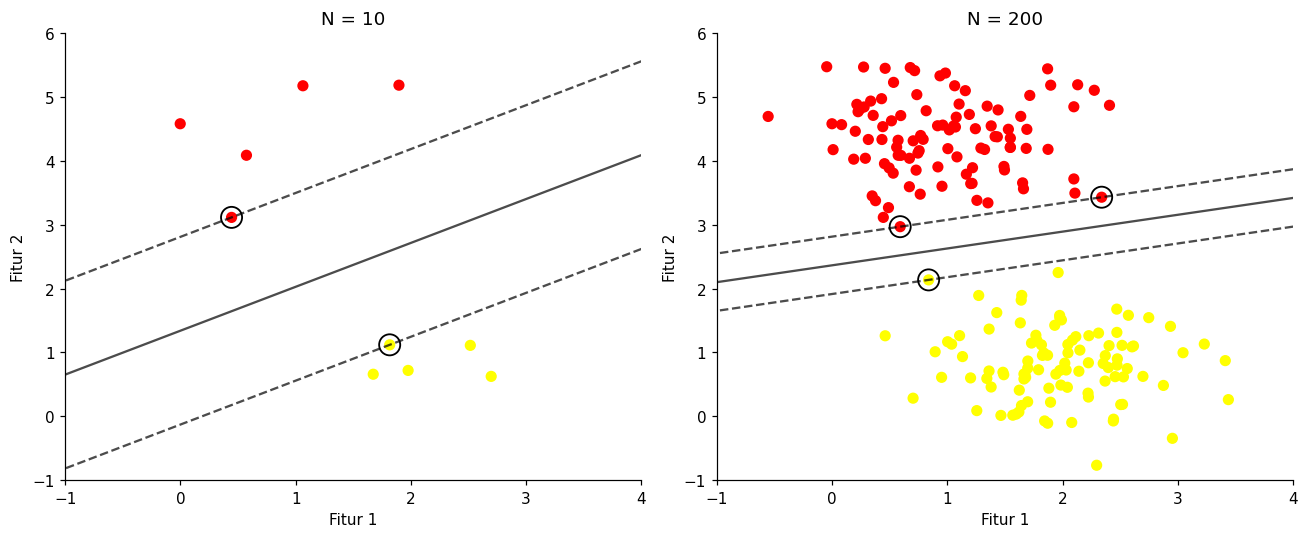

,support_vector,w1,w2,b,lebar_margin,akurasi_latih
N,,,,,,
10,2,0.467872,-0.680533,0.912524,2.421745,1.0
60,3,0.592278,-1.804677,4.359656,1.052974,1.0
120,3,0.592270,-1.804674,4.359655,1.052977,1.0
200,3,0.587218,-2.225980,5.264292,0.868760,1.0


Selisih maksimum koefisien/intercept N=60 vs 120: 0.00000791
Selisih maksimum koefisien/intercept N=10 vs 200: 4.35176849


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models.update({N: plot_svm(N, ax) for N, ax in zip([10, 200], axes)})
plt.tight_layout()
plt.show()

rows = []
for N in sorted(models):
    current = models[N]
    rows.append({"N": N, "support_vector": current.support_.size,
                 "w1": current.coef_[0, 0], "w2": current.coef_[0, 1],
                 "b": current.intercept_[0], "lebar_margin": 2 / np.linalg.norm(current.coef_),
                 "akurasi_latih": current.score(X_pool[:N], y_pool[:N])})
results = pd.DataFrame(rows).set_index("N")
display(results.round(6))
delta_60_120 = np.max(np.abs(np.r_[models[60].coef_.ravel(), models[60].intercept_] -
                            np.r_[models[120].coef_.ravel(), models[120].intercept_]))
delta_10_200 = np.max(np.abs(np.r_[models[10].coef_.ravel(), models[10].intercept_] -
                            np.r_[models[200].coef_.ravel(), models[200].intercept_]))
print(f"Selisih maksimum koefisien/intercept N=60 vs 120: {delta_60_120:.8f}")
print(f"Selisih maksimum koefisien/intercept N=10 vs 200: {delta_10_200:.8f}")


### Kesimpulan
- SVM memisahkan kelas dengan margin; support vector menentukan garisnya.
- Hasil 60 dan 120 data hampir sama, tetapi 10 dan 200 data berbeda.
- Akurasi di atas adalah akurasi latih, bukan akurasi data uji.

